<a href="https://colab.research.google.com/github/Bernpro/Soccer-World-Cup-Predictive/blob/main/World_Cup_England_vs_Argentina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- TOP 5 EXACT SCORE PREDICTIONS (ENGLAND VS ARGENTINA) ---
              Scoreline  Probability (%)
England 1 - 1 Argentina        10.453703
England 1 - 2 Argentina         9.199258
England 0 - 1 Argentina         7.466930
England 2 - 1 Argentina         7.317592
England 0 - 2 Argentina         6.570899

--- TOURNAMENT CHAMPION SIMULATION ODDS ---
  Country  Wins  Win Probability (%)
    Spain  5181                51.81
Argentina  2972                29.72
  England  1847                18.47


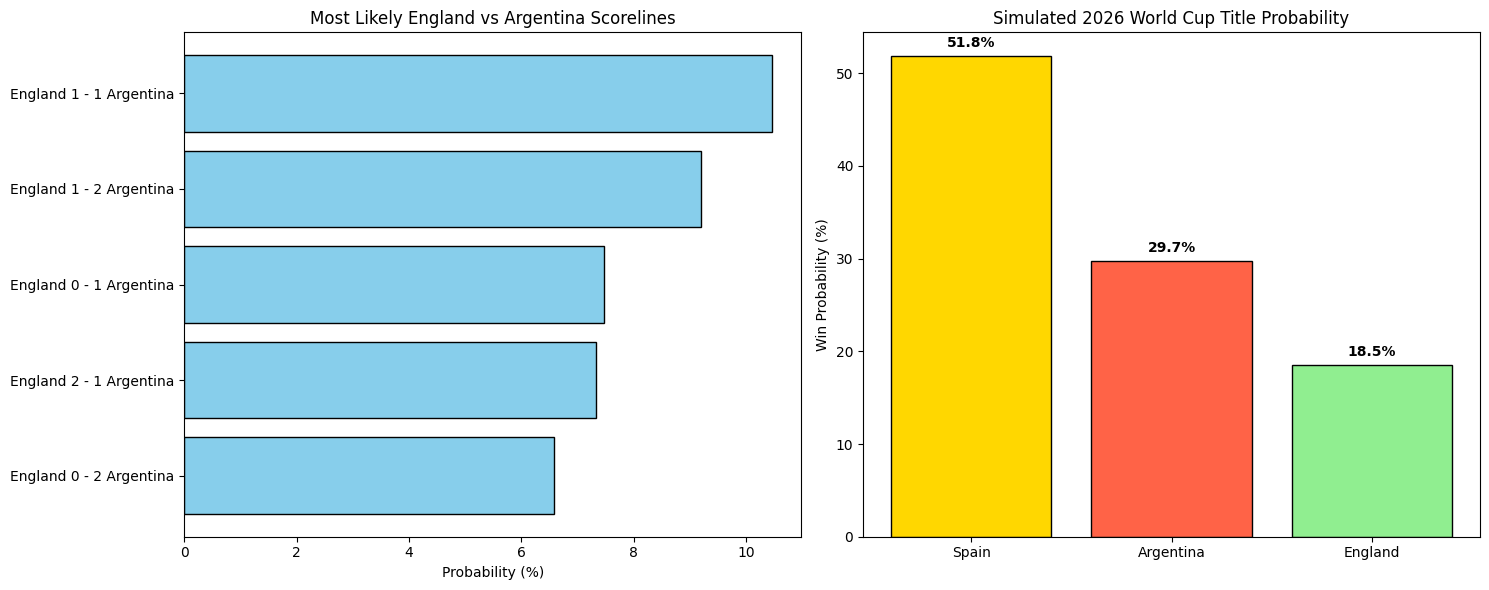

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import poisson

# 1. Real-World Live Data Inputs for Remaining Contenders
team_ratings = {
    "Spain": {"attack": 2.1, "defense": 0.7},  # Already qualified for the final
    "England": {"attack": 2.0, "defense": 0.8},
    "Argentina": {"attack": 2.2, "defense": 0.7},
}


# 2. Score Probabilities for England vs Argentina
def calculate_exact_scores(home, away):
    # Calculate lambda values (expected values) for the Poisson engine
    exp_home = team_ratings[home]["attack"] * team_ratings[away]["defense"]
    exp_away = team_ratings[away]["attack"] * team_ratings[home]["defense"]

    score_matrix = []
    # Loop over realistic goal lines (0 to 4 goals per team)
    for h_g in range(5):
        for a_g in range(5):
            # Compute independent joint probability of a specific score
            prob = poisson.pmf(h_g, exp_home) * poisson.pmf(a_g, exp_away) * 100
            score_matrix.append(
                {"Scoreline": f"{home} {h_g} - {a_g} {away}", "Probability (%)": prob}
            )

    df_scores = pd.DataFrame(score_matrix)
    return df_scores.sort_values(by="Probability (%)", ascending=False).head(5)


# 3. Quick Match Outcome Matrix Simulator
def simulate_match(home, away):
    exp_home = team_ratings[home]["attack"] * team_ratings[away]["defense"]
    exp_away = team_ratings[away]["attack"] * team_ratings[home]["defense"]

    h_g = np.random.poisson(exp_home)
    a_g = np.random.poisson(exp_away)

    if h_g > a_g:
        return home
    elif a_g > h_g:
        return away
    else:
        return np.random.choice([home, away])


# 4. Monte Carlo Loop (Remaining 2026 World Cup Bracket Track)
trophy_cabinet = {}
NUM_SIMULATIONS = 10000

for i in range(NUM_SIMULATIONS):
    # Semifinal 2 (Spain won Semifinal 1 already)
    semi_winner = simulate_match("England", "Argentina")
    # Grand Final
    champion = simulate_match("Spain", semi_winner)
    trophy_cabinet[champion] = trophy_cabinet.get(champion, 0) + 1

# Format Tournament Odds Dataframe
df_bracket = pd.DataFrame.from_dict(
    trophy_cabinet, orient="index", columns=["Wins"]
)
df_bracket["Win Probability (%)"] = (df_bracket["Wins"] / NUM_SIMULATIONS) * 100
df_bracket = df_bracket.sort_values(by="Wins", ascending=False).reset_index()
df_bracket.rename(columns={"index": "Country"}, inplace=True)


# 5. EXECUTION AND VISUAL PLOTTING IN COLAB
print("--- TOP 5 EXACT SCORE PREDICTIONS (ENGLAND VS ARGENTINA) ---")
df_top_scores = calculate_exact_scores("England", "Argentina")
print(df_top_scores.to_string(index=False))

print("\n--- TOURNAMENT CHAMPION SIMULATION ODDS ---")
print(df_bracket.to_string(index=False))

# Create side-by-side plot visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Exact Scorelines
ax1.barh(
    df_top_scores["Scoreline"],
    df_top_scores["Probability (%)"],
    color="skyblue",
    edgecolor="black",
)
ax1.set_title("Most Likely England vs Argentina Scorelines")
ax1.set_xlabel("Probability (%)")
ax1.invert_yaxis()

# Plot 2: World Cup Winners
ax2.bar(
    df_bracket["Country"],
    df_bracket["Win Probability (%)"],
    color=["gold", "tomato", "lightgreen"],
    edgecolor="black",
)
ax2.set_title("Simulated 2026 World Cup Title Probability")
ax2.set_ylabel("Win Probability (%)")
for i, v in enumerate(df_bracket["Win Probability (%)"]):
    ax2.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()
